<a href="https://colab.research.google.com/github/Fabiouxd/projeto-cardioIA-fase4/blob/main/parte1_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CardioIA — Fase 4
## Parte 1: Pré-processamento de Imagens Médicas

**Disciplina:** Inteligência Artificial e Visão Computacional  
**Instituição:** FIAP  
**Dataset:** Chest X-Ray Images (Pneumonia) — Kaggle  
**Integrantes:**
- Bernardo Rupolo
- Fabio Mendes
- Leonardo Magalhães
- Marcos Vinicius dos Santos Morgado

---

### Sobre o dataset

O dataset utilizado é o **Chest X-Ray Images (Pneumonia)**, disponível publicamente no Kaggle (Mooney, 2018). Ele contém 5.863 imagens de raios-X torácicos em dois grupos: `NORMAL` e `PNEUMONIA`. As imagens já estão organizadas em conjuntos de treino, validação e teste pelo próprio autor do dataset.

O dataset foi coletado do Guangzhou Women and Children's Medical Center e é amplamente utilizado em trabalhos acadêmicos de visão computacional aplicada à saúde.

**Referência:** Mooney, P. (2018). *Chest X-Ray Images (Pneumonia)*. Kaggle. https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

## 1. Instalação e Importações

In [ ]:
!pip install kaggle -q

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import Counter

SEED = 42
np.random.seed(SEED)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Download do Dataset

In [ ]:
import os

KAGGLE_TOKEN = 'KGAT_3e13af07d1a807ed002d1287a1579f36'
KAGGLE_USERNAME = 'fabiocmmc'

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

kaggle_json = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_TOKEN
}

import json as _json
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    _json.dump(kaggle_json, f)

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Autenticacao configurada com sucesso.')

Autenticacao configurada com sucesso.


In [ ]:
# Montar Google Drive para salvar o dataset permanentemente
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DATASET_DIR = '/content/drive/MyDrive/cardioIA_dataset/chest_xray'
BASE_DIR = '/content/data/chest_xray'

import os
print('Drive montado com sucesso.')
print(f'Dataset sera salvo em: {DRIVE_DATASET_DIR}')

Mounted at /content/drive
Drive montado com sucesso.
Dataset sera salvo em: /content/drive/MyDrive/cardioIA_dataset/chest_xray


In [ ]:
import shutil

# Verificar se dataset ja esta no Drive
if os.path.exists(DRIVE_DATASET_DIR):
    print('Dataset ja encontrado no Drive. Copiando para sessao local...')
    shutil.copytree(DRIVE_DATASET_DIR, BASE_DIR)
    print('Pronto.')
else:
    print('Dataset nao encontrado no Drive. Fazendo download do Kaggle...')
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/data/ --unzip
    print('Download concluido. Salvando no Drive para uso futuro...')
    os.makedirs(os.path.dirname(DRIVE_DATASET_DIR), exist_ok=True)
    shutil.copytree(BASE_DIR, DRIVE_DATASET_DIR)
    print(f'Dataset salvo em: {DRIVE_DATASET_DIR}')

Dataset nao encontrado no Drive. Fazendo download do Kaggle...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:11<00:00, 18.8MB/s]

Download concluido. Salvando no Drive para uso futuro...
Dataset salvo em: /content/drive/MyDrive/cardioIA_dataset/chest_xray


## 3. Exploração do Dataset

In [ ]:
BASE_DIR = '/content/data/chest_xray'
SPLITS = ['train', 'val', 'test']
CLASSES = ['NORMAL', 'PNEUMONIA']

# Contagem de imagens por split e classe
contagens = {}
for split in SPLITS:
    contagens[split] = {}
    for classe in CLASSES:
        caminho = os.path.join(BASE_DIR, split, classe)
        n = len(os.listdir(caminho)) if os.path.exists(caminho) else 0
        contagens[split][classe] = n

df_contagem = pd.DataFrame(contagens).T
df_contagem['Total'] = df_contagem.sum(axis=1)
print('Distribuicao do dataset original:')
print(df_contagem)

Distribuicao do dataset original:
       NORMAL  PNEUMONIA  Total
train    1341       3875   5216
val         8          8     16
test      234        390    624


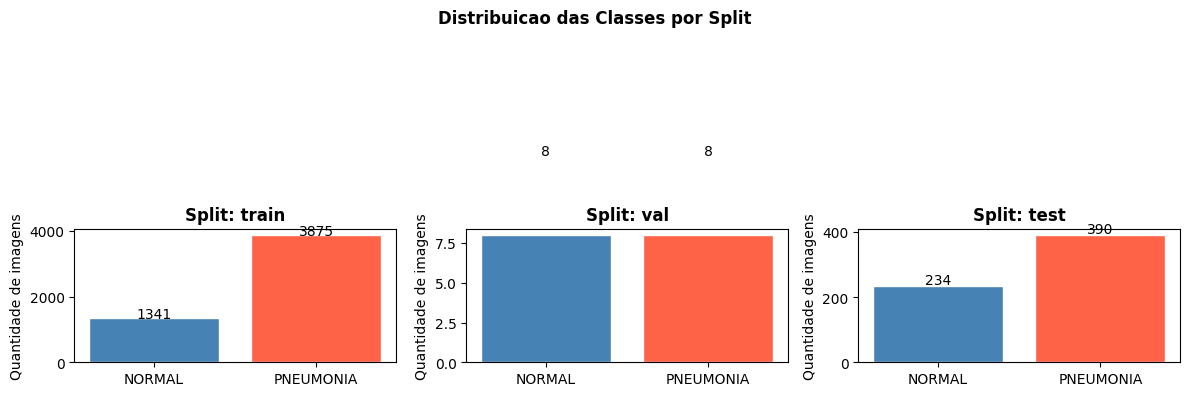

Observacao: O conjunto de treino apresenta desbalanceamento entre as classes, com maior numero de imagens de Pneumonia. Isso sera considerado na Parte 2.


In [ ]:
# Visualizacao da distribuicao
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, split in zip(axes, SPLITS):
    valores = [contagens[split][c] for c in CLASSES]
    ax.bar(CLASSES, valores, color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_title(f'Split: {split}', fontweight='bold')
    ax.set_ylabel('Quantidade de imagens')
    for i, v in enumerate(valores):
        ax.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.suptitle('Distribuicao das Classes por Split', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observacao: O conjunto de treino apresenta desbalanceamento entre as classes,'
      ' com maior numero de imagens de Pneumonia. Isso sera considerado na Parte 2.')

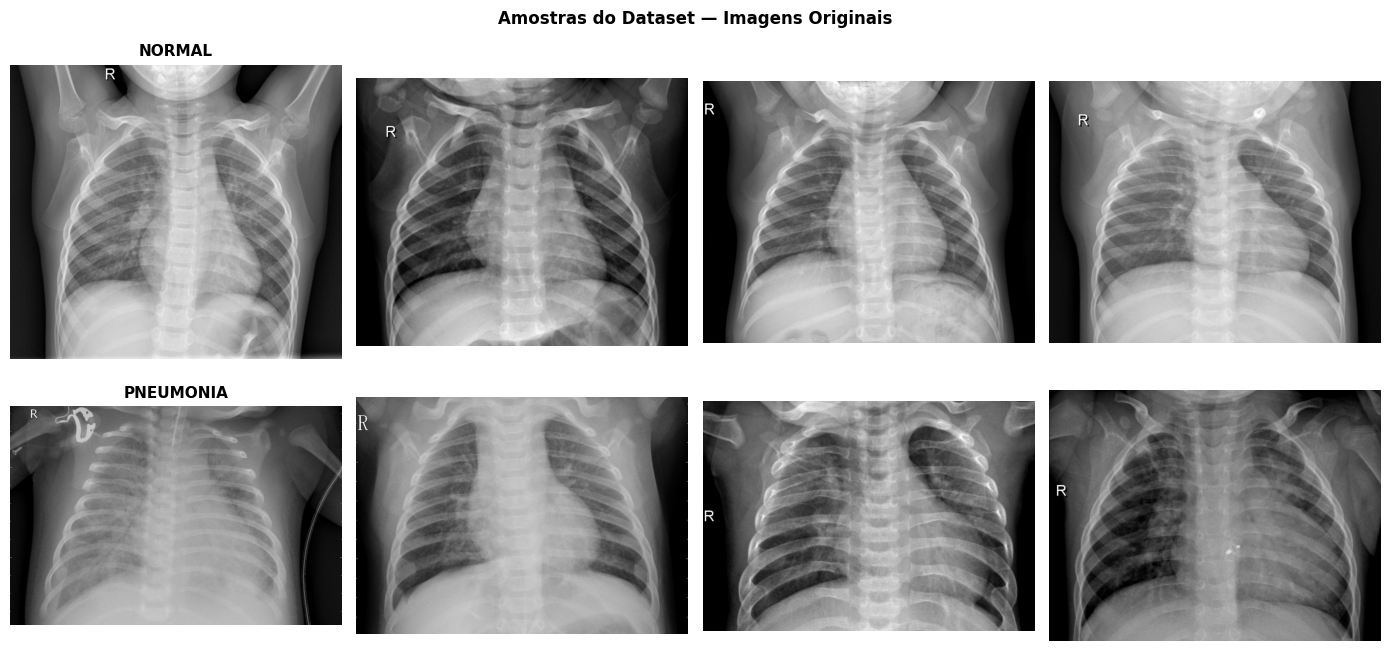

In [ ]:
# Amostras visuais do dataset original
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, classe in enumerate(CLASSES):
    dir_classe = os.path.join(BASE_DIR, 'train', classe)
    arquivos = sorted(os.listdir(dir_classe))[:4]
    for col, arq in enumerate(arquivos):
        img = cv2.imread(os.path.join(dir_classe, arq), cv2.IMREAD_GRAYSCALE)
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(classe, fontweight='bold', fontsize=11)

plt.suptitle('Amostras do Dataset — Imagens Originais', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/amostras_originais.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Pipeline de Pré-processamento

As seguintes etapas foram aplicadas a cada imagem:

1. **Leitura em escala de cinza** — raios-X sao imagens monocromaticas por natureza.
2. **Redimensionamento para 224x224 pixels** — padrao adotado pelos modelos VGG16 e ResNet utilizados na Parte 2.
3. **Aplicacao de CLAHE** (Contrast Limited Adaptive Histogram Equalization) — tecnica que melhora o contraste localmente, destacando estruturas sutis nos raios-X sem superexposicao de regioes brilhantes.
4. **Normalizacao para o intervalo [0, 1]** — reduz a escala dos valores de pixel, favorecendo a convergencia do modelo.
5. **Conversao para 3 canais (RGB)** — necessaria para compatibilidade com modelos pre-treinados em ImageNet.

In [ ]:
IMG_SIZE = (224, 224)

def preprocessar_imagem(caminho, tamanho=IMG_SIZE):
    """
    Aplica o pipeline de pre-processamento a uma imagem de raio-X.

    Etapas: leitura em grayscale, redimensionamento, CLAHE,
    normalizacao [0,1] e conversao para 3 canais (RGB).

    Args:
        caminho (str): caminho completo para a imagem.
        tamanho (tuple): dimensao de saida (largura, altura).

    Returns:
        numpy.ndarray: imagem processada com shape (H, W, 3), dtype float32.
    """
    img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, tamanho, interpolation=cv2.INTER_AREA)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = img.astype(np.float32) / 255.0
    img = np.stack([img, img, img], axis=-1)
    return img

print('Funcao de pre-processamento definida.')

Funcao de pre-processamento definida.


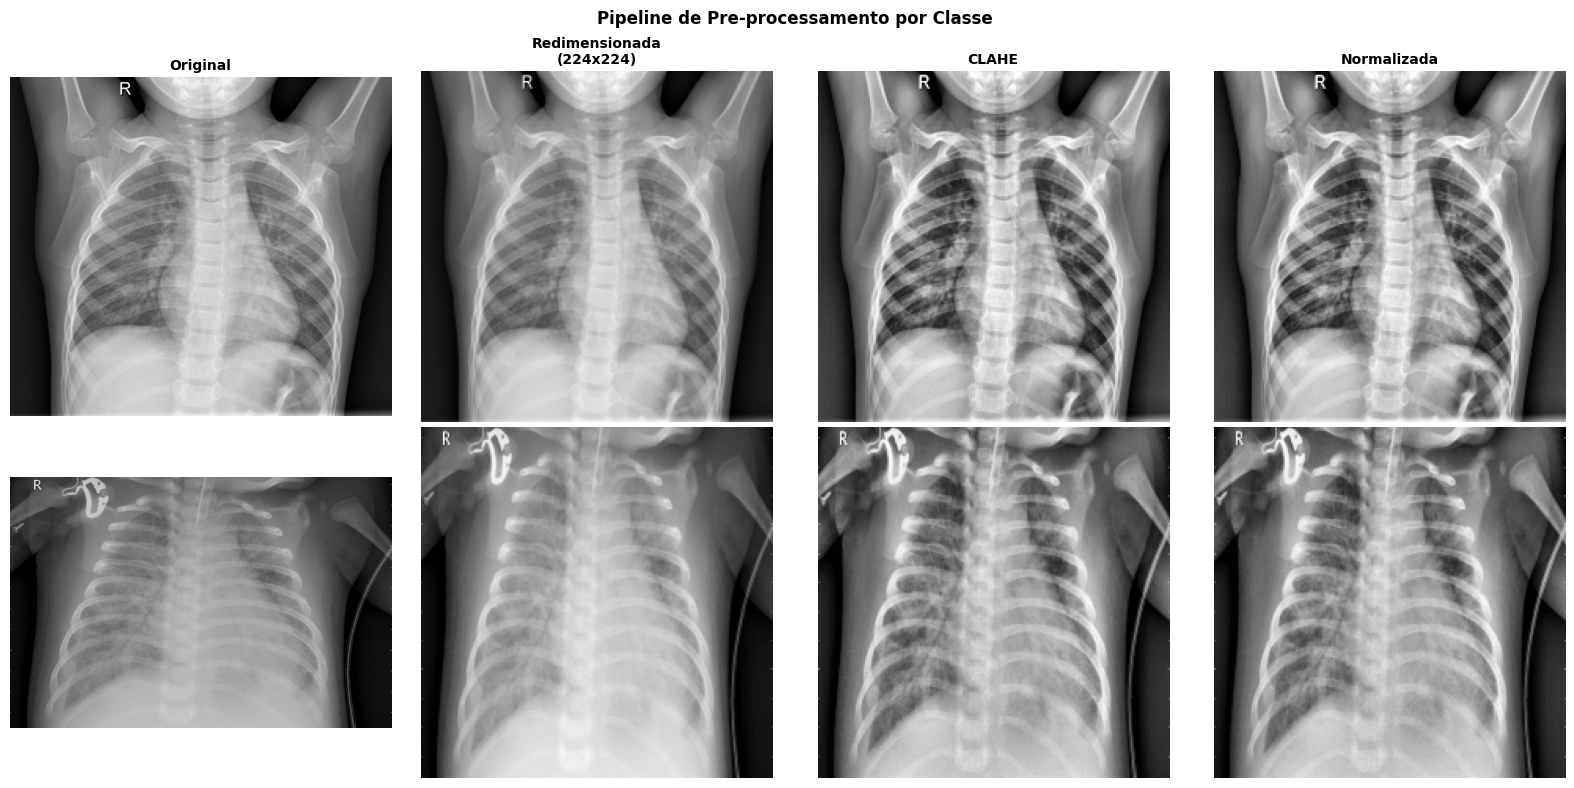

In [ ]:
# Demonstracao visual do pipeline em uma imagem de cada classe
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
etapas_titulos = ['Original', 'Redimensionada\n(224x224)', 'CLAHE', 'Normalizada']

for row, classe in enumerate(CLASSES):
    dir_classe = os.path.join(BASE_DIR, 'train', classe)
    arq = sorted(os.listdir(dir_classe))[0]
    caminho = os.path.join(dir_classe, arq)

    img_orig = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img_orig, IMG_SIZE, interpolation=cv2.INTER_AREA)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_resized)
    img_norm = img_clahe.astype(np.float32) / 255.0

    for col, (img, titulo) in enumerate(zip(
        [img_orig, img_resized, img_clahe, img_norm], etapas_titulos
    )):
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(titulo, fontsize=10, fontweight='bold')
        if col == 0:
            axes[row][col].set_ylabel(classe, fontsize=10, fontweight='bold',
                                      rotation=0, labelpad=60, va='center')

plt.suptitle('Pipeline de Pre-processamento por Classe', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/pipeline_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Geracao dos Conjuntos Processados

In [ ]:
OUTPUT_DIR = '/content/dataset_processado/'
erros = []

for split in SPLITS:
    for classe in CLASSES:
        dir_src = os.path.join(BASE_DIR, split, classe)
        dir_dst = os.path.join(OUTPUT_DIR, split, classe)
        os.makedirs(dir_dst, exist_ok=True)

        for arq in os.listdir(dir_src):
            if not arq.lower().endswith(('.jpeg', '.jpg', '.png')):
                continue
            caminho_src = os.path.join(dir_src, arq)
            caminho_dst = os.path.join(dir_dst, arq)
            try:
                img = preprocessar_imagem(caminho_src)
                img_uint8 = (img * 255).astype(np.uint8)
                cv2.imwrite(caminho_dst, img_uint8)
            except Exception as e:
                erros.append((arq, str(e)))

print(f'Pre-processamento concluido. Erros: {len(erros)}')
print(f'Dataset processado salvo em: {OUTPUT_DIR}')

Pre-processamento concluido. Erros: 0
Dataset processado salvo em: /content/dataset_processado/


## 6. Resumo do Pipeline

In [ ]:
total_processadas = sum(
    len(os.listdir(os.path.join(OUTPUT_DIR, s, c)))
    for s in SPLITS for c in CLASSES
    if os.path.exists(os.path.join(OUTPUT_DIR, s, c))
)

print('Resumo do Pipeline de Pre-processamento')
print('-' * 45)
print(f'Dataset:              Chest X-Ray (Pneumonia)')
print(f'Classes:              NORMAL, PNEUMONIA')
print(f'Tamanho das imagens:  224 x 224 px')
print(f'Canais:               3 (RGB)')
print(f'Normalizacao:         [0, 1]')
print(f'Melhoria de contraste: CLAHE (clipLimit=2.0)')
print(f'Total processadas:    {total_processadas}')
print(f'Erros:                {len(erros)}')
print('-' * 45)
print('Parte 1 concluida. Prosseguir para parte2_cnn_transfer.ipynb')

Resumo do Pipeline de Pre-processamento
---------------------------------------------
Dataset:              Chest X-Ray (Pneumonia)
Classes:              NORMAL, PNEUMONIA
Tamanho das imagens:  224 x 224 px
Canais:               3 (RGB)
Normalizacao:         [0, 1]
Melhoria de contraste: CLAHE (clipLimit=2.0)
Total processadas:    5856
Erros:                0
---------------------------------------------
Parte 1 concluida. Prosseguir para parte2_cnn_transfer.ipynb


## Referencia

Mooney, P. (2018). *Chest X-Ray Images (Pneumonia)*. Kaggle.  
Disponivel em: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

Kermany, D. et al. (2018). *Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning*. Cell, 172(5), 1122-1131.